Nombres de los integrantes del grupo:

- Romario Aponte
- Kamila Viteri

nombramiento del archivo: P1_Grupo_8

## <center>Ejercicio práctico semana 1</center>

<b>Maestría</b>: Inteligencia Artificial Aplicada <br>
<b>Asignatura:</b> Procesamiento Acelerado de Lenguaje Natural <br>
<b>Profesor:</b> Edwin J. Rueda

**Bienvenidos** al ejercicio práctico de la primera semana. A parte de las preguntas prácticas y teóricas que deberás responder, ten en cuenta lo siguiente:
- Encontrarás enlaces a documentación externa que te ayudará a resolver dudas.
- Resuelve los ejercicios de forma secuencial. Para que puedas ver el avance.
- La idea es guiarte sobre el proceso, por lo cual, encontrarás funciones pre-definidas.
    Por lo cual deberás colocar el código faltante dentro de las etiquetas especificadas.
- Encontrarás una salida esperada en cada celda para que tengas una guía. (Ten en cuenta que una vez ejecutada la celda, esta salida desaparecera).

In [26]:
# Instalación de dependencias necesarias (usando magics para asegurar el entorno correcto)
%pip install nltk spacy wordcloud
import sys
!{sys.executable} -m spacy download es_core_news_sm


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 11.3 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


### Dataset

Para este ejercicio práctico utilizaremos una fracción del dataset de MeLi. El dataset cuenta con 60k registros, los cuales hacen referencia al titulo de un producto y a su respectiva categoria. El objetivo del entregable es realizar un procesamiento del conjunto de datos con los métodos vistos en clase. Finalmente, veremos como se reduce la dimensionalidad y que tokens se vuelven más relevantes.

El dataset cuenta con la siguiente información:

    - title: Descripción del titúlo del producto
    - category: Categoria a la cual pertenece el producto

#### Descargar y visualizar el conjunto de datos

El conjunto de datos se encuentra público y puedes descargarlo [aquí](https://drive.google.com/file/d/1ivgFoL4HXwmc0u9n-rPR5c5U5lt5_Eds/view?usp=sharing). En este ejemplo, estará sobre la misma ruta donde se encuentra el notebook, por lo cual lo leemos con la función *read_csv* de [Pandas](https://pandas.pydata.org/docs/).

In [1]:
import pandas as pd
from time import time
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
data = pd.read_csv("./filter_data.csv", index_col=0)
data.head()

,title,category
0,Campera Ls2 Hombre Discovery Black Solo En Mg ...,MOTORCYCLE_JACKETS
1,Peine Beiyuan 13 Dientes,COMBS
2,Collar Arranque Fiat Palio Siena Strada Pin Fi...,IGNITION_SWITCH_ACTUATORS
3,Lampara Compatible Benq Ms517f Por Pedido,PROJECTOR_LAMPS
4,Canilla Doble Esférico Riego Prog Lavarropa Fv...,IRRIGATION_VALVES


Primeramente, podemos obtener estadisticas de los datos:

In [4]:
print(f"Dimensionalidad de los datos: {data.shape}")
print(f"Cantidad de categorias de productos: {len(data.category.unique())}")

Dimensionalidad de los datos: (60000, 2)
Cantidad de categorias de productos: 1543


In [5]:
data.describe()

,title,category
count,60000,60000
unique,59824,1543
top,My Little Pony Paraguas + Toallon + Cartuchera...,FOOTBALL_SHIRTS
freq,2,137


Algo muy útil es entender la distribución de los datos, en este caso en particular, de las categorías. Esto no permitirá entender los resultados obtenidos en nuestro modelo de aprendizaje supervisado. Para ello, podemos hacer uso del método *groupby* y *count*:

In [31]:
categories = data.groupby("category").count()
categories.head()

,title
category,
3D_GLASSES,10
3D_PRINTERS,20
3D_PRINTER_FILAMENTS,28
ABDOMINAL_TONING_BELTS,5
ABS_SENSORS,42


Otra buena práctica es observar la distribución de los datos. En este caso resulta útil ver la distribución de las categorías. Lo que nos permite enteder un poco mas a detalle los resultados que tengan nuestros modelos de AI.

In [32]:
categories.sort_values(by="title")

,title
category,
MODELISM_SERVO_MOTORS,1
MARTIAL_ARTS_CHEST_GUARDS,1
MEAT_HOOKS,1
MOTORCYCLE_EXHAUSTS,1
BDSM_WHIPS,1
...,...
REFRIGERATORS,121
SPARK_PLUGS,124
MINI_COMPONENT_SYSTEMS,126


Podemos obtener la cantidad de palabras únicas en nuestro conjunto de datos antes de ser preprocesado:

In [33]:
data_init_word_count = len(np.unique(' '.join(data['title']).split()))
print(f"Tamaño inicial de palabras únicas del dataset: {data_init_word_count} palabras")

Tamaño inicial de palabras únicas del dataset: 75794 palabras


### Pregunta 1

##### ¿Crees que para los pasos de pre-procesamiento de los datos influya el tener categorías con un solo producto y otras con mas de 100 productos?

Sí, influye significativamente. Las categorías con un solo producto sufren del problema de "escasez de datos", lo que dificulta que el modelo aprenda patrones representativos. Durante el pre-procesamiento, si eliminamos términos clave que son únicos para esa categoría (como stopwords que podrían ser parte de un nombre propio), corremos el riesgo de perder la única señal disponible. Además, el desbalanceo puede hacer que el vocabulario esté sesgado hacia las palabras de las categorías más frecuentes.

### Pre-procesamiento del corpus

Para el preprocesamiento del corpus, desarrollaremos dos *pipelines*:
- Stemmer_pipeline: Este, como su nombre lo indica, se basará en sacar la raíz de las palabras. No obstante, hará los siguentes pasos:
  1. Llevará todas las palabras a minúsculas
  2. Eliminará las *stopwords*
  3. hará stemming de todo el corpus.
 
- Lemma_pipeline: Este, a diferencia del *Stemmer_pipeline*, realizará lematización de las palabras:
  1. Llevará todas las palabras a minúsculas
  2. Eliminará las *stopwords*
  3. Obtendrá el *lemma* de cada palabra.

#### Ejercicio 1
Se debe construir una función que dado un string, retorne dicho string en minúsculas:

In [34]:
def get_lower_case(sentence):
    ### TU CÓDIGO AQUÍ ###
    result = sentence.lower()
    ######################
    return result

example = data.iloc[19]["title"]
lower_example = get_lower_case(example)
print(f"Sentencia original -> {example}")
print(f"Sentencia procesada -> {lower_example}")

Sentencia original -> Zapatilla Importada Azul Niño Talle 29 En Temperley!!!
Sentencia procesada -> zapatilla importada azul niño talle 29 en temperley!!!


#### Ejercicio 2

Ahora podemos calcular la reducción de la dimensionalidad después de llevar el corpus a minúsculas. ¿Cuantas palabras se redujimos?

In [35]:
### TU CODIGO AQUÍ ###
data_lower = data['title'].apply(get_lower_case)
data_lower_word_count = len(np.unique(' '.join(data_lower).split()))

print(f"Tamaño de palabras únicas después de aplicar lower case: {data_lower_word_count} palabras")
print(f"Reducción de la dimensionalidad: {data_init_word_count - data_lower_word_count} Palabras")
######################

Tamaño de palabras únicas después de aplicar lower case: 75627 palabras
Reducción de la dimensionalidad: 167 Palabras


#### Ejercicio 3
Ahora vamos a construir la función para eliminar las stopwords. Para ello, es necesario que cumpla lo siguiente:
- Recibir como entrada un string en minúsculas
- Iterar sobre cada palabra dentro del string para poder descartar las *stopwords*
- Retornar la nueva oración sin *stopwords*

In [ ]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

spanish_stop_words = set(stopwords.words("spanish"))

def delete_stop_words(sentence):
    ### TÚ CÓDIGO AQUÍ ###
    # Optimizamos moviendo la creación del set fuera de la función
    result = " ".join([word for word in sentence.split() if word not in spanish_stop_words])
    ######################
    return result


print(f"Sentencia original -> {lower_example}")
example_sw = delete_stop_words(lower_example)
print(f"Sentencia sin stopwords -> {example_sw}") 

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/romarioaponte/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
print(f"Sentencia original -> {lower_example}")
example_sw = delete_stop_words(lower_example)
print(f"Sentencia sin stopwords -> {example_sw}")

Sentencia original -> zapatilla importada azul niño talle 29 en temperley!!!
Sentencia sin stopwords -> zapatilla importada azul niño talle 29 temperley!!!


#### Ejercicio 4

Ahora podemos calcular la reducción de la dimensionalidad después de eliminar del **corpus con lowercasing** las stop words. ¿Cuantas palabras se redujimos?

In [38]:
### TU CODIGO AQUÍ ###
data_sw = data_lower.apply(delete_stop_words)
data_sw_word_count = len(np.unique(' '.join(data_sw).split()))

print(f"Tamaño de palabras únicas después de eliminar stop words: {data_sw_word_count} palabras")
print(f"Reducción de la dimensionalidad: {data_lower_word_count - data_sw_word_count} Palabras")
######################

Tamaño de palabras únicas después de eliminar stop words: 75519 palabras
Reducción de la dimensionalidad: 108 Palabras


### Pregunta 2

##### ¿Crees que las mayúsculas o las *stopwords* pueden aportar a esta tarea y que eliminarlas sea un error?

Depende del contexto. En títulos de productos, las mayúsculas a veces resaltan marcas o características importantes (ej. "Talle XL" vs "xl"). Sin embargo, eliminarlas suele ser beneficioso para normalizar el vocabulario. Las stopwords, aunque suelen ser ruido, en algunos casos pueden formar parte de nombres de productos específicos. No obstante, para tareas de clasificación masiva, su eliminación es una práctica estándar para reducir la dimensionalidad y enfocarse en los términos con mayor carga semántica.

#### Ejercicio 5

Crear una función que nos permita lematizar las palabras/tokens dentro de unas sentencia y nos retorne la nueva sentencia lematizada:

In [39]:
import spacy
nlp_pipe = spacy.load("es_core_news_sm") 

In [40]:
def get_lemmas(sentence):
    ### TÚ CÓDIGO AQUÍ ###
    doc = nlp_pipe(sentence)
    result = " ".join([token.lemma_ for token in doc])
    ######################
    return result

print(f"Sentencia original -> {example_sw}")
example_lemma = get_lemmas(example_sw)
print(f"Sentencia lemmatizada -> {example_lemma}")

Sentencia original -> zapatilla importada azul niño talle 29 temperley!!!
Sentencia lemmatizada -> zapatilla importado azul niño talle 29 temperley ! ! !


#### Ejercicio 6
Crear una función para sacar la raíz de cada palabra dentro de una oración y retornar la sentencia nueva procesada:

In [41]:
from nltk.stem.snowball import SnowballStemmer

def get_stemmer(sentence):
    ### TU CÓDIGO AQUÍ ###
    stemmer = SnowballStemmer('spanish')
    result = " ".join([stemmer.stem(word) for word in sentence.split()])
    ######################
    return result

print(f"Sentencia original -> {example_sw}")
example_stemmer = get_stemmer(example_sw)
print(f"Sentencia stemming -> {example_stemmer}")

Sentencia original -> zapatilla importada azul niño talle 29 temperley!!!
Sentencia stemming -> zapatill import azul niñ tall 29 temperley!!!


#### **Ejercicio 7:**

Ahora podemos calcular la reducción de la dimensionalidad después de hacer stemming sobre el corpus con **lowercasing y sin stop words** ¿Cuantas palabras se redujimos?

In [42]:
### TU CODIGO AQUÍ ###
data_stemmer_temp = data_sw.apply(get_stemmer)
data_stemmer_word_count = len(np.unique(' '.join(data_stemmer_temp).split()))

print(f"Tamaño de palabras únicas después de hacer stemming: {data_stemmer_word_count} palabras")
print(f"Reducción de la dimensionalidad: {data_sw_word_count - data_stemmer_word_count} Palabras")
######################

Tamaño de palabras únicas después de hacer stemming: 66102 palabras
Reducción de la dimensionalidad: 9417 Palabras


#### **Ejercicio 8:**

Con las funciones de procesamiento definidas, construiremos nuestra función *pipeline*, la cual procesará los datos dependiendo de un parámetro de entrada que define si queremos sacar el *lemma* o el *stemmer* de los tokens.

Nuestra función *pipeline* debe cumplir con los siguientes requisitos:
- recibir como entrada los siguientes parámetros:
    - df: dataframe con las columnas *title* y *category*
    - method: string identificando si es *stemmer* o *lemma* el procesado
- debe retornar el nuevo dataframe procesado, manteniendo el nombre de las columnas

In [1]:
def pipeline(df, method="stemmer"):
    """
    df: dataframe 
    method: stemmer o lemma
    """
    df = df.copy()
    # Pre-procesamiento inicial (Lower case y Stopwords)
    print(f"Iniciando pre-procesamiento ({method})...")
    texts = [delete_stop_words(get_lower_case(t)) for t in df["title"]]
    
    if method == "stemmer":
        stemmer = SnowballStemmer('spanish')
        df["title"] = [" ".join([stemmer.stem(w) for w in t.split()]) for t in texts]
    elif method == "lemma":
        # USAMOS nlp.pipe PARA PROCESAMIENTO EN LOTES (MUCHO MÁS RÁPIDO)
        lemmas = []
        for doc in nlp_pipe.pipe(texts, batch_size=500):
            lemmas.append(" ".join([token.lemma_ for token in doc]))
        df["title"] = lemmas
        
    return df

Procesamos el dataset con el método *stemmer*:

In [44]:
tic = time()
data_stemmer = pipeline(data, method="stemmer")
toc = time()
print(f"Tiempo de procesamiento: {(toc-tic)/60} [min]")
data_stemmer.head()

Iniciando pre-procesamiento (stemmer)...
Tiempo de procesamiento: 0.06951544682184856 [min]


,title,category
0,camper ls2 hombr discovery black sol mg bik,MOTORCYCLE_JACKETS
1,pein beiyu 13 dient,COMBS
2,coll arranqu fiat pali sien strad pin fin 140mm,IGNITION_SWITCH_ACTUATORS
3,lamp compat benq ms517f ped,PROJECTOR_LAMPS
4,canill dobl esfer rieg prog lavarrop fv 436.04...,IRRIGATION_VALVES


Procesamos el dataset con el método *lemma*

In [45]:
tic = time()
data_lemma = pipeline(data, method="lemma")
toc = time()
print(f"Tiempo de procesamiento: {(toc-tic)/60} [min]")
data_lemma.head()

Iniciando pre-procesamiento (lemma)...
Tiempo de procesamiento: 1.301220683256785 [min]


,title,category
0,camperar ls2 hombre discovery black solo mg bikes,MOTORCYCLE_JACKETS
1,peine beiyuan 13 diente,COMBS
2,collar arrancar fiat palio siena strado pin fi...,IGNITION_SWITCH_ACTUATORS
3,lampar compatible benq ms517f pedido,PROJECTOR_LAMPS
4,canilla doble esférico riego prog lavarropa fv...,IRRIGATION_VALVES


### Analicemos los resultados del procesado

Una de las formas sencillas de obtener una vista inicial de la frecuencia de los *tokens* en el corpus es mediante un [word cloud](https://github.com/amueller/word_cloud/blob/main/README.md). Con este, podemos visualmente observar que tanto cambio la frecuencia al aplicar el *stemming* o la *lemmatization*

In [46]:
!pip install wordcloud

zsh:1: command not found: pip


Para poder crear el *word cloud* necesitamos generar un único corpus:

In [47]:
corpus_init = " ".join(row["title"] for indx, row in data.iterrows())
corpus_lemma = " ".join(row["title"] for indx, row in data_lemma.iterrows())
corpus_stemmer = " ".join(row["title"] for indx, row in data_stemmer.iterrows())

In [48]:
from wordcloud import WordCloud

wc_init = WordCloud(background_color="white").generate(corpus_init)
wc_lemma = WordCloud(background_color="white").generate(corpus_lemma)
wc_stemmer = WordCloud(background_color="white").generate(corpus_stemmer)

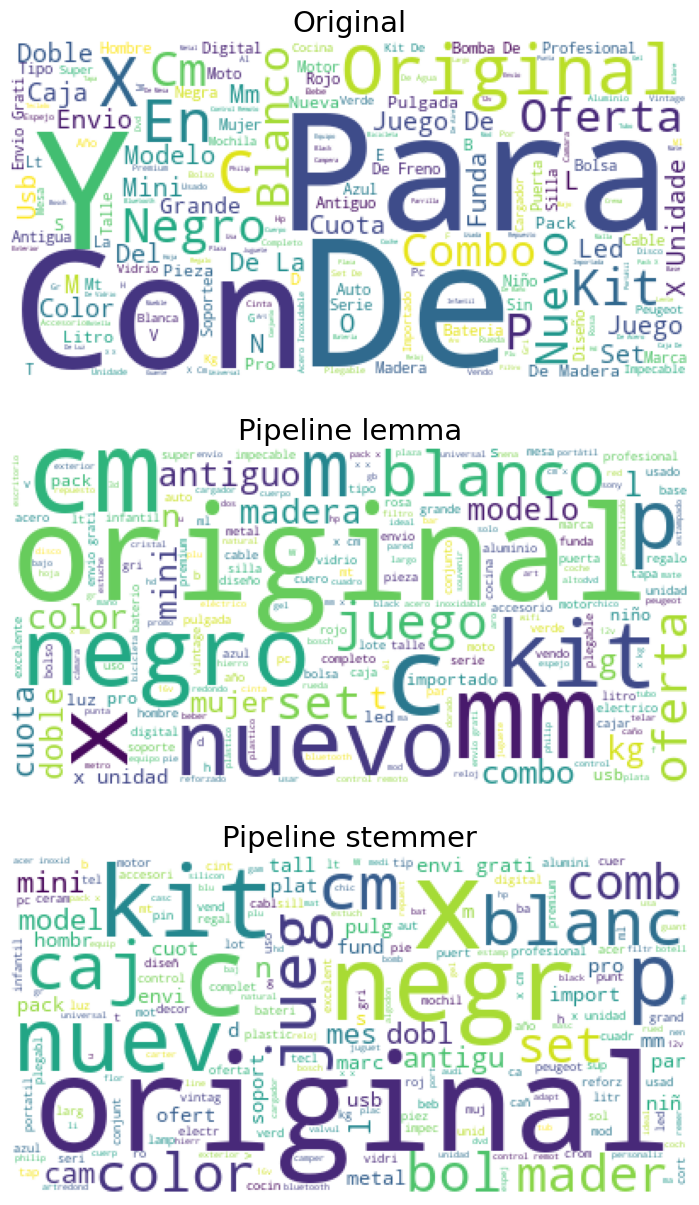

In [49]:
plt.figure(figsize=(20,15))
for i, wc_obj, title in zip(range(3),
                     [wc_init, wc_lemma, wc_stemmer],
                     ["Original", "Pipeline lemma", "Pipeline stemmer"]):
    plt.subplot(3,1,i+1)
    plt.title(title, fontsize=21)
    plt.imshow(wc_obj)
    plt.axis("off")

### Pregunta 3

##### Genera una conclusión de lo que logras observar en los word cloud. ¿Hubo variación en la frencuencia de los *tokens*? 

Se observa una clara evolución. En la nube original, aparecen muchas variaciones de una misma palabra (plurales, géneros). En la nube de Stemming, las palabras se reducen a su raíz, lo que aumenta visualmente la frecuencia de los términos "base" (ej. 'zapatill' en lugar de 'zapatilla', 'zapatillas'). En la Lematización, las palabras son legibles y están normalizadas a su forma canónica (infinitivos, singulares masculinos), lo que permite una interpretación más clara de los temas dominantes del dataset sin perder la estructura gramatical básica.

#### Ejercicio 9

Nota que generamos 3 corpus (*corpus_init*, *corpus_lemma*, *corpus_stemmer*). A partir de estos tres corpus, concluye como cambió la dimensionalidad de cada corpus y el por qué cambió.

In [50]:
### TU CÓDIGO ASÍ ###
corpus_init_word_count = len(np.unique(corpus_init.split()))
corpus_lemma_word_count = len(np.unique(corpus_lemma.split()))
corpus_stemmer_word_count = len(np.unique(corpus_stemmer.split()))

print(f"Vocabulario Original: {corpus_init_word_count}")
print(f"Vocabulario Lema: {corpus_lemma_word_count}")
print(f"Vocabulario Stemmer: {corpus_stemmer_word_count}")

print(f"Reducción con Lematización: {corpus_init_word_count - corpus_lemma_word_count}")
print(f"Reducción con Stemming: {corpus_init_word_count - corpus_stemmer_word_count}")
#####################

Vocabulario Original: 75794
Vocabulario Lema: 64923
Vocabulario Stemmer: 66102
Reducción con Lematización: 10871
Reducción con Stemming: 9692


**Conclusión sobre la Reducción de Dimensionalidad:**

Al analizar los resultados, observamos que las técnicas de normalización reducen significativamente el tamaño del vocabulario único del corpus:

1. **Corpus Original (75,794 palabras):** Posee la mayor dimensionalidad ya que mantiene todas las variaciones flexivas (género, número, conjugaciones verbales) y derivativas de las palabras.
2. **Corpus con Lematización (64,923 palabras):** Logró la mayor reducción (10,871 palabras menos). Esto cambió porque la lematización analiza gramaticalmente el texto y agrupa las distintas formas flexivas bajo su lema o forma de diccionario (ej. transformando plurales a singulares de forma inteligente con Spacy).
3. **Corpus con Stemming (66,102 palabras):** Redujo el vocabulario en 9,692 palabras. El cambio se debe a que el stemming aplica reglas heurísticas (Snowball) para cortar los sufijos de las palabras y quedarse con la raíz. Aunque suele ser muy agresivo, en este dataset en particular, la lematización basada en contexto (Spacy) logró agrupar de manera más eficiente las variaciones del vocabulario en español de los títulos de productos.

### Pregunta 4

##### ¿Cómo podrías emplear lo visto en tu ámbito profesional? ¿Consideras útil implementar solo esta parte, o crees que se debería complementar con otras técnicas de NLP?

**1. Aplicación en el ámbito profesional:**
En el sector bancario (mi enfoque profesional), estas técnicas son fundamentales para el procesamiento y clasificación automática de glosas de transferencias, la detección de fraudes mediante el análisis de patrones en los conceptos de pago, y la organización de reclamos o sugerencias de clientes. Al normalizar el texto, podemos identificar la intención del usuario de manera más robusta, independientemente de variaciones gramaticales o errores de escritura menores.

**2. Utilidad y complemento con otras técnicas:**
Considero que implementar solo el pre-procesamiento es un primer paso crítico para asegurar la calidad de los datos, pero es insuficiente por sí solo. Para obtener valor real, debe complementarse con técnicas de representación vectorial (como Word2Vec, FastText o BERT) y modelos de aprendizaje supervisado o no supervisado. El pre-procesamiento actúa como el filtro necesario para reducir el ruido, permitiendo que los algoritmos posteriores se enfoquen en la semántica y el contexto relevante de la información financiera.